In [ ]:
!pip install gtts

In [ ]:
!pip install SpeechRecognition


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.8/32.8 MB 46.5 MB/s eta 0:00:00


In [ ]:
!pip install pydub
!sudo apt-get install ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.


In [ ]:
!pip -q install kaggle

In [ ]:
import random
from PIL import Image
from gtts import gTTS
import IPython.display as ipd
from collections import Counter
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import speech_recognition as sr
from pydub import AudioSegment


In [ ]:
import tensorflow as tf
import os
import json
import pandas as pd
import re
import numpy as np
import time
import matplotlib.pyplot as plt
import collections
import random
import requests
from math import sqrt
from PIL import Image
from tqdm.auto import tqdm

In [ ]:
if not os.path.exists('/content/data/'):

    api_token = {"username": "<-- your username -->",
                 "key": "<-- your api key -->"}

    with open('/content/kaggle.json', 'w') as file:
        json.dump(api_token, file)

    os.environ["KAGGLE_CONFIG_DIR"] = "/content/"

    os.system('kaggle datasets download -d adityajn105/flickr8k')
    os.makedirs('/content/data/', exist_ok=True)
    os.system('mv /content/flickr8k.zip /content/data/flickr8k.zip')
    os.system('unzip -q /content/data/flickr8k.zip -d /content/data/')
    os.remove('/content/data/flickr8k.zip')

In [ ]:
captions = pd.read_csv('/content/data/captions.txt')
captions['image'] = captions['image'].apply(
    lambda x: f'/content/data/Images/{x}')
captions.head()

,image,caption
0,/content/data/Images/1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,/content/data/Images/1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,/content/data/Images/1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,/content/data/Images/1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,/content/data/Images/1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [ ]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub('\s+', ' ', text)
    text = text.strip()
    text = '[start] ' + text + ' [end]'
    return text

In [ ]:
captions['caption'] = captions['caption'].apply(preprocess)
captions.head()

,image,caption
0,/content/data/Images/1000268201_693b08cb0e.jpg,[start] a child in a pink dress is climbing up...
1,/content/data/Images/1000268201_693b08cb0e.jpg,[start] a girl going into a wooden building [end]
2,/content/data/Images/1000268201_693b08cb0e.jpg,[start] a little girl climbing into a wooden p...
3,/content/data/Images/1000268201_693b08cb0e.jpg,[start] a little girl climbing the stairs to h...
4,/content/data/Images/1000268201_693b08cb0e.jpg,[start] a little girl in a pink dress going in...


[start] a large yellow dog is retrieving a stick [end]



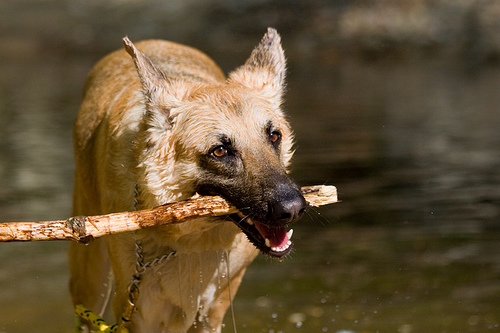

In [ ]:
random_row = captions.sample(1).iloc[0]
print(random_row.caption)
print()
im = Image.open(random_row.image)
im

In [ ]:
tts = gTTS(text=random_row.caption, lang='en')
audio_file = 'random_caption.mp3'
tts.save(audio_file)

# Play the audio file
ipd.display(ipd.Audio(audio_file))

In [ ]:
MAX_LENGTH = 40
VOCABULARY_SIZE = 10000
BATCH_SIZE = 128
BUFFER_SIZE = 1000
EMBEDDING_DIM = 512
UNITS = 512

In [ ]:
tokenizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCABULARY_SIZE,
    standardize=None,
    output_sequence_length=MAX_LENGTH)

tokenizer.adapt(captions['caption'])

In [ ]:
word2idx = tf.keras.layers.StringLookup(
    mask_token="",
    vocabulary=tokenizer.get_vocabulary())

idx2word = tf.keras.layers.StringLookup(
    mask_token="",
    vocabulary=tokenizer.get_vocabulary(),
    invert=True)

In [ ]:
img_to_cap_vector = collections.defaultdict(list)
for img, cap in zip(captions['image'], captions['caption']):
    img_to_cap_vector[img].append(cap)

img_keys = list(img_to_cap_vector.keys())
random.shuffle(img_keys)

slice_index = int(len(img_keys)*0.8)
img_name_train_keys, img_name_val_keys = (img_keys[:slice_index],
                                          img_keys[slice_index:])

train_imgs = []
train_captions = []
for imgt in img_name_train_keys:
    capt_len = len(img_to_cap_vector[imgt])
    train_imgs.extend([imgt] * capt_len)
    train_captions.extend(img_to_cap_vector[imgt])

val_imgs = []
val_captions = []
for imgv in img_name_val_keys:
    capv_len = len(img_to_cap_vector[imgv])
    val_imgs.extend([imgv] * capv_len)
    val_captions.extend(img_to_cap_vector[imgv])

In [ ]:
len(train_imgs), len(train_captions), len(val_imgs), len(val_captions)

(32360, 32360, 8095, 8095)

In [ ]:
def load_data(img_path, caption):
    img = tf.io.read_file(img_path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.keras.layers.Resizing(299, 299)(img)
    img = img / 255.
    caption = tokenizer(caption)
    return img, caption

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_imgs, train_captions))

train_dataset = train_dataset.map(
    load_data, num_parallel_calls=tf.data.AUTOTUNE
    ).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_imgs, val_captions))

val_dataset = val_dataset.map(
    load_data, num_parallel_calls=tf.data.AUTOTUNE
    ).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

In [ ]:
image_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomContrast(0.3),
    ]
)

In [ ]:
def CNN_Encoder():
    inception_v3 = tf.keras.applications.InceptionV3(
        include_top=False,
        weights='imagenet'
    )
    inception_v3.trainable = False

    output = inception_v3.output
    output = tf.keras.layers.Reshape(
        (-1, output.shape[-1]))(output)

    cnn_model = tf.keras.models.Model(inception_v3.input, output)
    return cnn_model

In [ ]:
class TransformerEncoderLayer(tf.keras.layers.Layer):

    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.layer_norm_1 = tf.keras.layers.LayerNormalization()
        self.layer_norm_2 = tf.keras.layers.LayerNormalization()
        self.attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim)
        self.dense = tf.keras.layers.Dense(embed_dim, activation="relu")


    def call(self, x, training):
        x = self.layer_norm_1(x)
        x = self.dense(x)

        attn_output = self.attention(
            query=x,
            value=x,
            key=x,
            attention_mask=None,
            training=training
        )

        x = self.layer_norm_2(x + attn_output)
        return x

In [ ]:
class Embeddings(tf.keras.layers.Layer):

    def __init__(self, vocab_size, embed_dim, max_len):
        super().__init__()
        self.token_embeddings = tf.keras.layers.Embedding(
            vocab_size, embed_dim)
        self.position_embeddings = tf.keras.layers.Embedding(
            max_len, embed_dim, input_shape=(None, max_len))


    def call(self, input_ids):
        length = tf.shape(input_ids)[-1]
        position_ids = tf.range(start=0, limit=length, delta=1)
        position_ids = tf.expand_dims(position_ids, axis=0)

        token_embeddings = self.token_embeddings(input_ids)
        position_embeddings = self.position_embeddings(position_ids)

        return token_embeddings + position_embeddings

In [ ]:
Embeddings(tokenizer.vocabulary_size(), EMBEDDING_DIM, MAX_LENGTH)(next(iter(train_dataset))[1]).shape

TensorShape([128, 40, 512])

In [ ]:
class TransformerDecoderLayer(tf.keras.layers.Layer):

    def __init__(self, embed_dim, units, num_heads, num_layers):
        super().__init__()
        self.embedding = Embeddings(
            tokenizer.vocabulary_size(), embed_dim, MAX_LENGTH)

        self.attention_layers = []
        self.ffn_layers = []

        for _ in range(num_layers):
            self.attention_layers.append(
                tf.keras.layers.MultiHeadAttention(
                    num_heads=num_heads, key_dim=embed_dim, dropout=0.1
                )
            )
            self.ffn_layers.append(
                tf.keras.Sequential([
                    tf.keras.layers.Dense(units, activation="relu"),
                    tf.keras.layers.Dropout(0.3),
                    tf.keras.layers.Dense(embed_dim)
                ])
            )

        self.layernorms_1 = [tf.keras.layers.LayerNormalization() for _ in range(num_layers)]
        self.layernorms_2 = [tf.keras.layers.LayerNormalization() for _ in range(num_layers)]
        self.layernorms_3 = [tf.keras.layers.LayerNormalization() for _ in range(num_layers)]

        self.out = tf.keras.layers.Dense(tokenizer.vocabulary_size(), activation="softmax")

        self.dropout_1 = tf.keras.layers.Dropout(0.3)
        self.dropout_2 = tf.keras.layers.Dropout(0.5)


    def call(self, input_ids, encoder_output, training, mask=None):
        embeddings = self.embedding(input_ids)

        combined_mask = None
        padding_mask = None

        if mask is not None:
            causal_mask = self.get_causal_attention_mask(embeddings)
            padding_mask = tf.cast(mask[:, :, tf.newaxis], dtype=tf.int32)
            combined_mask = tf.cast(mask[:, tf.newaxis, :], dtype=tf.int32)
            combined_mask = tf.minimum(combined_mask, causal_mask)

        for i in range(len(self.attention_layers)):
            attn_output_1 = self.attention_layers[i](
                query=embeddings,
                value=embeddings,
                key=embeddings,
                attention_mask=combined_mask,
                training=training
            )

            out_1 = self.layernorms_1[i](embeddings + attn_output_1)

            attn_output_2 = self.attention_layers[i](
                query=out_1,
                value=encoder_output,
                key=encoder_output,
                attention_mask=padding_mask,
                training=training
            )

            out_2 = self.layernorms_2[i](out_1 + attn_output_2)

            ffn_out = self.ffn_layers[i](out_2)
            ffn_out = self.dropout_1(ffn_out, training=training)

            ffn_out = self.layernorms_3[i](ffn_out + out_2)
            ffn_out = self.dropout_2(ffn_out, training=training)

            embeddings = ffn_out

        preds = self.out(ffn_out)
        return preds


    def get_causal_attention_mask(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size, sequence_length = input_shape[0], input_shape[1]
        i = tf.range(sequence_length)[:, tf.newaxis]
        j = tf.range(sequence_length)
        mask = tf.cast(i >= j, dtype="int32")
        mask = tf.reshape(mask, (1, input_shape[1], input_shape[1]))
        mult = tf.concat(
            [tf.expand_dims(batch_size, -1), tf.constant([1, 1], dtype=tf.int32)],
            axis=0
        )
        return tf.tile(mask, mult)


In [ ]:
class ImageCaptioningModel(tf.keras.Model):

    def __init__(self, cnn_model, encoder, decoder, image_aug=None):
        super().__init__()
        self.cnn_model = cnn_model
        self.encoder = encoder
        self.decoder = decoder
        self.image_aug = image_aug
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.acc_tracker = tf.keras.metrics.Mean(name="accuracy")


    def calculate_loss(self, y_true, y_pred, mask):
        loss = self.loss(y_true, y_pred)
        mask = tf.cast(mask, dtype=loss.dtype)
        loss *= mask
        return tf.reduce_sum(loss) / tf.reduce_sum(mask)


    def calculate_accuracy(self, y_true, y_pred, mask):
        accuracy = tf.equal(y_true, tf.argmax(y_pred, axis=2))
        accuracy = tf.math.logical_and(mask, accuracy)
        accuracy = tf.cast(accuracy, dtype=tf.float32)
        mask = tf.cast(mask, dtype=tf.float32)
        return tf.reduce_sum(accuracy) / tf.reduce_sum(mask)


    def compute_loss_and_acc(self, img_embed, captions, training=True):
        encoder_output = self.encoder(img_embed, training=True)
        y_input = captions[:, :-1]
        y_true = captions[:, 1:]
        mask = (y_true != 0)
        y_pred = self.decoder(
            y_input, encoder_output, training=True, mask=mask
        )
        loss = self.calculate_loss(y_true, y_pred, mask)
        acc = self.calculate_accuracy(y_true, y_pred, mask)
        return loss, acc


    def train_step(self, batch):
        imgs, captions = batch

        if self.image_aug:
            imgs = self.image_aug(imgs)

        img_embed = self.cnn_model(imgs)

        with tf.GradientTape() as tape:
            loss, acc = self.compute_loss_and_acc(
                img_embed, captions
            )

        train_vars = (
            self.encoder.trainable_variables + self.decoder.trainable_variables
        )
        grads = tape.gradient(loss, train_vars)
        self.optimizer.apply_gradients(zip(grads, train_vars))
        self.loss_tracker.update_state(loss)
        self.acc_tracker.update_state(acc)

        return {"loss": self.loss_tracker.result(), "acc": self.acc_tracker.result()}


    def test_step(self, batch):
        imgs, captions = batch

        img_embed = self.cnn_model(imgs)

        loss, acc = self.compute_loss_and_acc(
            img_embed, captions, training=False
        )

        self.loss_tracker.update_state(loss)
        self.acc_tracker.update_state(acc)

        return {"loss": self.loss_tracker.result(), "acc": self.acc_tracker.result()}

    @property
    def metrics(self):
        return [self.loss_tracker, self.acc_tracker]

In [ ]:
encoder = TransformerEncoderLayer(EMBEDDING_DIM, num_heads=1)
decoder = TransformerDecoderLayer(EMBEDDING_DIM, UNITS, num_heads=1,num_layers=8)

cnn_model = CNN_Encoder()
caption_model = ImageCaptioningModel(
    cnn_model=cnn_model, encoder=encoder, decoder=decoder, image_aug=image_augmentation,
)


In [ ]:
cross_entropy = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False, reduction="none"
)

early_stopping = tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

caption_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=cross_entropy
)

In [ ]:
history = caption_model.fit(
    train_dataset,
    epochs=100,
    validation_data=val_dataset,
    callbacks=[early_stopping]
)

Epoch 1/10
253/253 [==============================] - 372s 1s/step - loss: 5.5472 - acc: 0.1215 - val_loss: 5.4092 - val_acc: 0.1317
Epoch 2/10
253/253 [==============================] - 296s 1s/step - loss: 5.3349 - acc: 0.1295 - val_loss: 5.3581 - val_acc: 0.1327
Epoch 3/10
253/253 [==============================] - 296s 1s/step - loss: 5.3156 - acc: 0.1305 - val_loss: 5.3424 - val_acc: 0.1320
Epoch 4/10
253/253 [==============================] - ETA: 0s - loss: 5.2656 - acc: 0.1305

In [ ]:
idx2word(2).numpy().decode('utf-8')

'a'

In [ ]:
def load_image_from_path(img_path):
    img = tf.io.read_file(img_path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.keras.layers.Resizing(299, 299)(img)
    img = img / 255.
    return img


def generate_caption(img_path):
    img = load_image_from_path(img_path)
    img = tf.expand_dims(img, axis=0)
    img_embed = caption_model.cnn_model(img)
    img_encoded = caption_model.encoder(img_embed, training=False)

    y_inp = '[start]'
    for i in range(MAX_LENGTH-1):
        tokenized = tokenizer([y_inp])[:, :-1]
        mask = tf.cast(tokenized != 0, tf.int32)
        pred = caption_model.decoder(
            tokenized, img_encoded, training=False, mask=mask)

        pred_idx = np.argmax(pred[0, i, :])
        pred_word = idx2word(pred_idx).numpy().decode('utf-8')
        if pred_word == '[end]':
            break

        y_inp += ' ' + pred_word

    y_inp = y_inp.replace('[start] ', '')
    return y_inp

Predicted Caption: a black dog is running on the sand



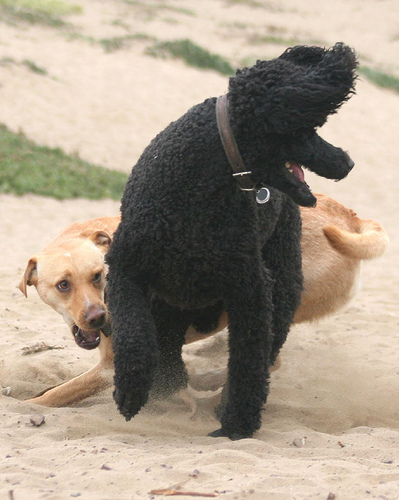

In [ ]:
idx = random.randrange(0, len(val_imgs))
img_path = val_imgs[idx]

pred_caption = generate_caption(img_path)
print('Predicted Caption:', pred_caption)
print()
Image.open(img_path)


In [ ]:
tts = gTTS(text=pred_caption, lang='en')
audio_file = 'predicted_caption.mp3'
tts.save(audio_file)

# Play the audio file
ipd.display(ipd.Audio(audio_file))

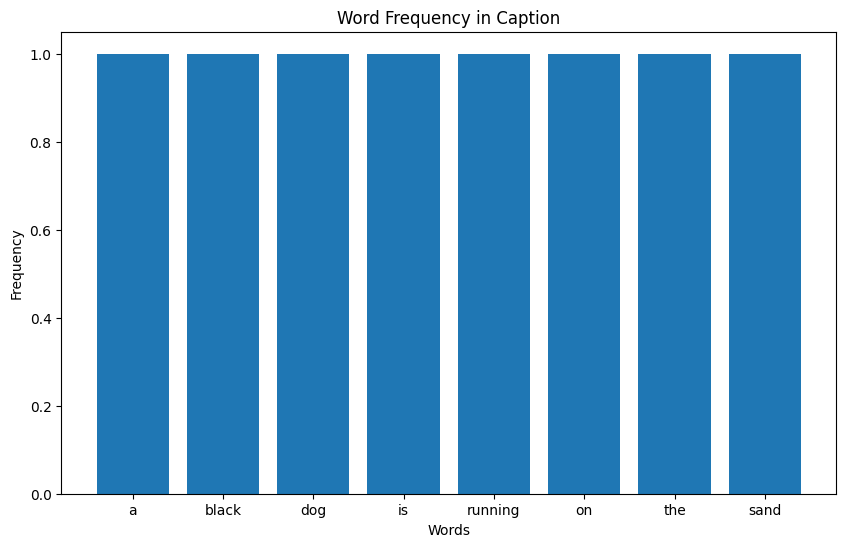

In [ ]:
def plot_word_frequencies(caption):
    # Tokenize the caption and convert to lowercase
    words = re.findall(r'\w+', caption.lower())

    # Count the frequency of each word
    word_counts = Counter(words)

    # Separate the words and their frequencies
    words, counts = zip(*word_counts.items())

    # Create a bar graph
    plt.figure(figsize=(10, 6))
    plt.bar(words, counts)
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.title('Word Frequency in Caption')
    plt.show()

# Plot word frequencies in the generated caption
plot_word_frequencies(pred_caption)

In [ ]:
# Function to generate a caption for a given image
def generate_caption(img_path):
    img = load_image_from_path(img_path)
    img = tf.expand_dims(img, axis=0)
    img_embed = caption_model.cnn_model(img)
    img_encoded = caption_model.encoder(img_embed, training=False)

    y_inp = '[start]'
    for i in range(MAX_LENGTH-1):
        tokenized = tokenizer([y_inp])[:, :-1]
        mask = tf.cast(tokenized != 0, tf.int32)
        pred = caption_model.decoder(tokenized, img_encoded, training=False, mask=mask)
        pred_idx = np.argmax(pred[0, i, :])
        pred_word = idx2word(pred_idx).numpy().decode('utf-8')
        if pred_word == '[end]':
            break
        y_inp += ' ' + pred_word

    y_inp = y_inp.replace('[start] ', '')
    return y_inp

In [ ]:
# Function to evaluate the caption accuracy using BLEU score
def evaluate_caption_accuracy(val_imgs, val_captions, num_samples=100):
    bleu_scores = []
    smooth = SmoothingFunction().method4
    for i in range(num_samples):
        idx = random.randrange(0, len(val_imgs))
        img_path = val_imgs[idx]
        ground_truth = val_captions[idx]
        generated_caption = generate_caption(img_path)
        bleu_score = sentence_bleu([ground_truth.split()], generated_caption.split(), smoothing_function=smooth)
        bleu_scores.append(bleu_score)
    avg_bleu_score = np.mean(bleu_scores)
    print(f"Average BLEU Score: {avg_bleu_score}")
    return avg_bleu_score
bleu_score = evaluate_caption_accuracy(val_imgs, val_captions)


Average BLEU Score: 0.05479646724556888


In [ ]:
# Function to transcribe audio using speech recognition
def transcribe_audio(audio_file):
    recognizer = sr.Recognizer()
    with sr.AudioFile(audio_file) as source:
        audio = recognizer.record(source)
    return recognizer.recognize_google(audio)

In [ ]:

# Function to convert MP3 to WAV
def convert_mp3_to_wav(mp3_file, wav_file):
    audio = AudioSegment.from_mp3(mp3_file)
    audio.export(wav_file, format="wav")

In [ ]:
# Function to evaluate the audio transcription accuracy
def evaluate_audio_accuracy(val_imgs, num_samples=10):
    accuracy_scores = []
    for i in range(num_samples):
        idx = random.randrange(0, len(val_imgs))
        img_path = val_imgs[idx]
        generated_caption = generate_caption(img_path)
        tts = gTTS(text=generated_caption, lang='en')
        mp3_file = 'predicted_caption.mp3'
        wav_file = 'predicted_caption.wav'
        tts.save(mp3_file)
        convert_mp3_to_wav(mp3_file, wav_file)
        transcribed_caption = transcribe_audio(wav_file)
        if generated_caption == transcribed_caption:
            accuracy_scores.append(1)
        else:
            accuracy_scores.append(0)
    audio_accuracy = np.mean(accuracy_scores)
    print(f"Audio Accuracy: {audio_accuracy}")
    return audio_accuracy
audio_accuracy = evaluate_audio_accuracy(val_imgs)

Audio Accuracy: 0.8


In [ ]:
# Combine the scores to get an overall accuracy metric
overall_accuracy = (bleu_score + audio_accuracy) / 2
print(f"Overall Accuracy: {overall_accuracy}")


Overall Accuracy: 0.42739823362278445
